# **Moment, Sıralama, Yaklaşıklaştırma ve Konturları Eşleştirme**

####**Bu derste şunları öğreneceğiz:**
1. Konturları Alana Göre Sıralama
2. Soldan Sağa Sıralama
3. Yaklaşık Konturlar
4. Dışbükey Gövde

In [29]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 16):
    """Robust display helper: handles None and grayscale images.
    
    - Raises ValueError if image is None (clearer than AttributeError).
    - Displays grayscale images with a gray colormap.
    - Displays BGR images by converting to RGB for matplotlib.
    """
    if image is None:
        raise ValueError(f"imshow: image is None for '{title}'")
    h, w = image.shape[:2]
    aspect_ratio = h / w if w != 0 else 1
    plt.figure(figsize=(size * aspect_ratio, size))
    if image.ndim == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

### **Konturları her zamanki gibi bulma**

Attempting to load image from: y:\MASAÜSTÜ\BilgisayarliGoru2025.V01\files\images\america13.jpg


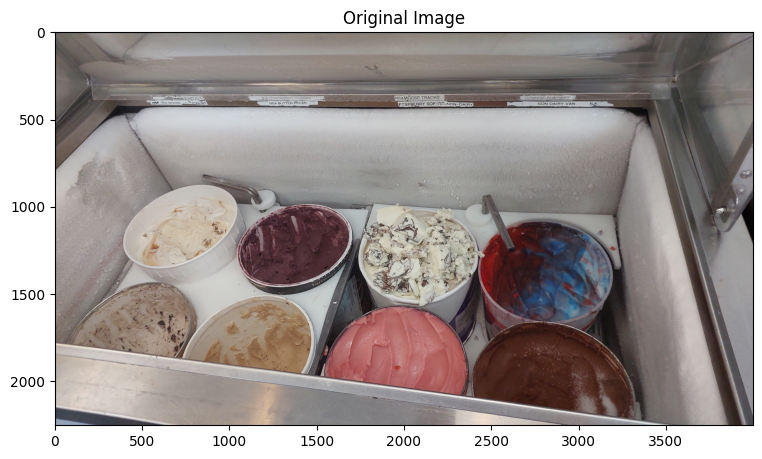

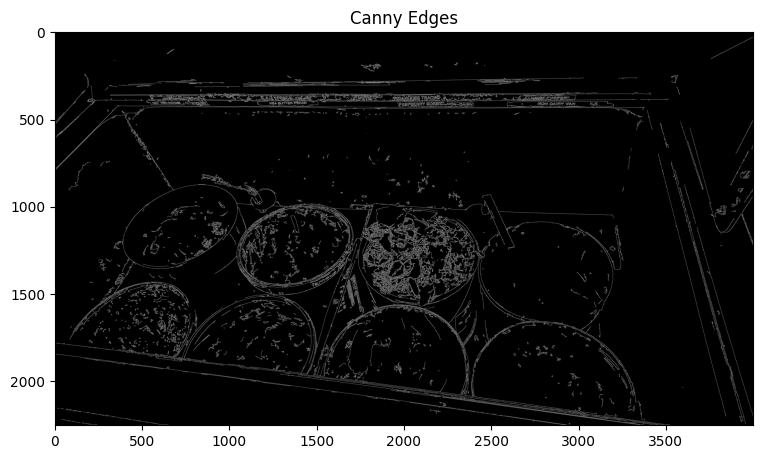

Number of contours found =  3246


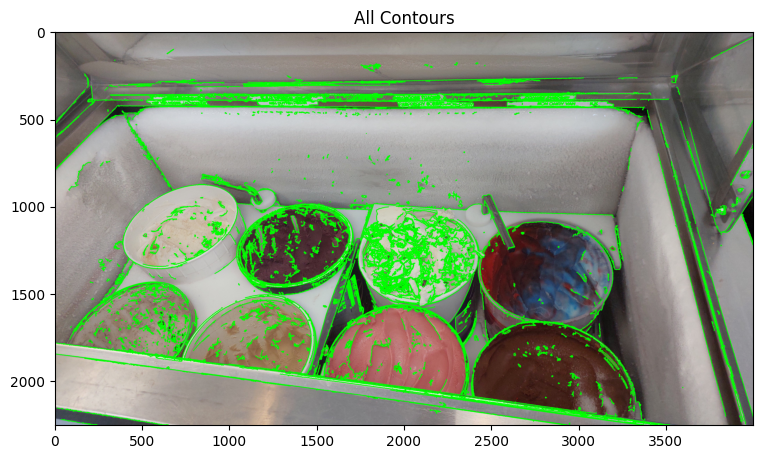

In [4]:
# Resmimizi yükleyelim
import os
# Varsayılan dosya yolunu oluşturun (notebook çalışma dizinine göre göreli)
img_path = os.path.join('..','files','images','america13.jpg')
# Eğer .jpg yoksa .jpeg uzantılı dosyayı deneyin (workspace'te .jpeg mevcut olabilir)
if not os.path.exists(img_path):
    alt = os.path.join('..','files','images','america13.jpeg')
    if os.path.exists(alt):
        img_path = alt
print(f'Attempting to load image from: {os.path.abspath(img_path)}')
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Failed to load image. Tried: {os.path.abspath(img_path)}. Check that the file exists and is readable.")
imshow('Original Image', image)

# Görüntümüzü gri tonlayalım
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

# Canny kenarlarını bulalım
edged = cv2.Canny(gray, 50, 200)
imshow('Canny Edges', edged)

# Konturları bulun ve kaç tane bulunduğunu yazdırın
contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
print("Number of contours found = ", len(contours))

# Tüm konturları boş görüntü üzerine çizin
cv2.drawContours(image, contours, -1, (0,255,0), 3)
imshow('All Contours', image)

## ** cv2.ContourArea ve cv2.Moments kullanarak Alana göre sıralama**


Sıralama Öncesi Kontor Alanları...
[0.5, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 12.0, 4.0, 3.0, 0.0, 0.0, 5.0, 4.0, 1.0, 0.0, 0.5, 0.0, 4.5, 0.0, 1.0, 5.0, 1.0, 1.0, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, 0.0, 0.0, 0.0, 3.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 30.0, 0.0, 0.0, 0.0, 1.0, 1.0, 10.0, 0.5, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 8.0, 0.0, 0.0, 1.5, 0.0, 2.0, 0.0, 18.5, 0.0, 0.0, 0.0, 0.0, 1.5, 0.0, 0.0, 0.0, 3.5, 1.0, 0.0, 1.0, 0.0, 1.5, 0.0, 0.0, 0.0, 1.5, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 21.0, 3.0, 7.0, 0.5, 1.5, 8.5, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 28.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 25.5, 10.5, 0.0, 0.0, 28.5, 0.0, 0.0, 1.0, 0.0, 0.0, 1.5, 78.5, 0.0, 0.0, 0.0, 10.0, 4.5, 11.0, 0.0, 0.0, 0.0, 3.5, 0.0, 1.0, 0.0, 3.0, 9.5, 15.5, 0.0, 11.0, 29.5, 1.5, 0.0, 0.0, 23.0, 7.5, 2.0, 1.0, 13.0, 3.0, 0.0, 0.0, 14.5, 4.0, 0.0, 2.0, 0.0, 8.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 9.5, 10.5, 7.0, 3.5, 33.5, 9.0,

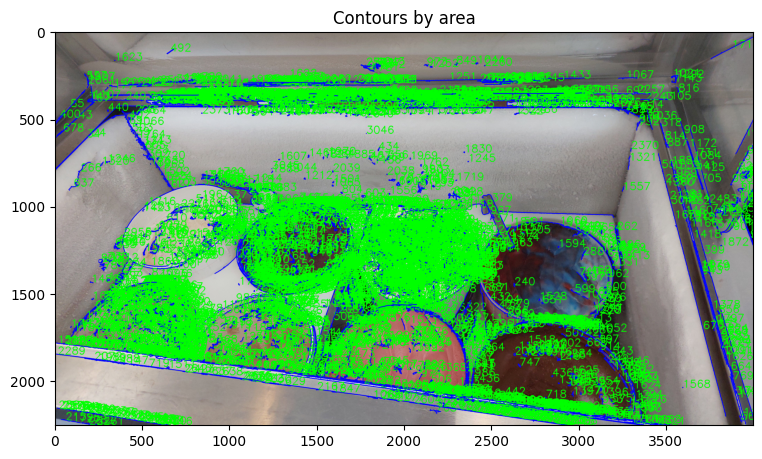

In [7]:
import cv2
import numpy as np

# Her Konturun alanını bulmak için kullanacağımız fonksiyon
def get_contour_areas(contours):
    """returns the areas of all contours as list"""
    all_areas = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        all_areas.append(area)
    return all_areas

# Resmimizi yükleyelim
image = cv2.imread('../files/images/america13.jpg')

# Sıralamadan önce konturların alanlarını yazdıralım
print("Sıralama Öncesi Kontor Alanları...")
print(get_contour_areas(contours))

# Konturları alana göre büyükten küçüğe doğru sıralayalım
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

print("Sıralama Sonrası Kontor Alanları...") 
print(get_contour_areas(sorted_contours))

# Konturlarımız üzerinde gezerek her seferinde bir tane yazalım
#cv2.moments(c) → konturun geometrik özelliklerini çıkarır.
#En sık kullanılanı: alan (m00) ve ağırlık merkezi (m10/m00, m01/m00).
#Daha ileri momentler → şeklin yönü, eğikliği, simetrisi gibi bilgileri çıkarır.
for (i,c) in enumerate(sorted_contours):
    M = cv2.moments(c)
    # M['m00'] is the contour area; if it's zero, avoid division-by-zero
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        # Fallback: use bounding rectangle center for zero-area contours
        x, y, w, h = cv2.boundingRect(c)
        cx = int(x + w/2)
        cy = int(y + h/2)
    cv2.putText(image, str(i+1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3)
    cv2.drawContours(image, [c], -1, (255,0,0), 3)

imshow('Contours by area', image)

#### **Kullanacağımız bazı fonksiyonları tanımlayalım**

In [10]:
# Pozisyona göre sıralama için kullanacağımız fonksiyonlar
def x_cord_contour(contours):
    """Kontur merkezinin X koordinatını döndürür"""
    # Filtre olarak çok küçük konturları göz ardı et (gürültü)
    if cv2.contourArea(contours) > 10:
        M = cv2.moments(contours)
        # m00 sıfırsa momentlere bölme hatasını önlemek için yedek hesaplama kullan
        if M['m00'] != 0:
            return int(M['m10']/M['m00'])
        else:
            x, y, w, h = cv2.boundingRect(contours)
            return int(x + w/2)
    else:
        # Çok küçük konturlar için sıralamada kararlı bir dönüş değeri döndürün
        return 0
    
def label_contour_center(image, c):
    """Konturların merkezlerine kırmızı bir daire yerleştirir"""
    M = cv2.moments(c)
    # m00 sıfırsa (bölme hatası) bounding rect merkezini kullan
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        x, y, w, h = cv2.boundingRect(c)
        cx = int(x + w/2)
        cy = int(y + h/2)
    
    # Görüntü üzerine kontur numarasını çizin
    cv2.circle(image,(cx,cy), 10, (0,0,255), -1)
    return image

#### **Merkezi Hesaplamak için Momentleri kullanırız ve ardından soldan sağa sıralamak için X Koordinatını kullanırız**

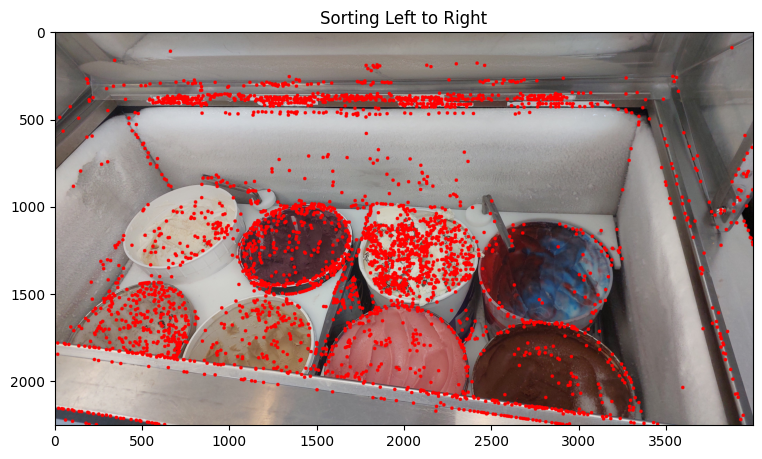

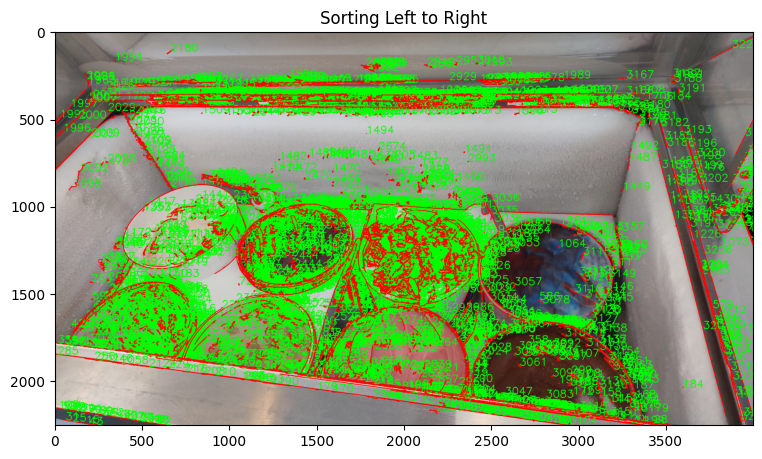

In [12]:
# Resmimizi yükleyelim
image = cv2.imread('../files/images/america13.jpg')
orginal_image = image.copy()

# Kütle Merkezini veya merkezlerini hesaplayın ve bunları resmimizin üzerine çizin
for (i, c) in enumerate(contours):
    orig = label_contour_center(image, c)
 
# Kontur merkezlerini gösterelim
imshow("Sorting Left to Right", image)

# x_cord_contour fonksiyonumuzu kullanarak soldan sağa doğru sıralayın
# x_cord_contour fonksiyonu sıralama sırasında contours içindeki değerlere tek tek uygulanır. 
contours_left_to_right = sorted(contours, key = x_cord_contour, reverse = False)

# Konturları soldan sağa etiketleme
# enumerate, bir listeyi döngüyle gezerken hem elemanın kendisini hem de indeksini (sırasını) aynı anda verir.
for (i,c)  in enumerate(contours_left_to_right):
    cv2.drawContours(orginal_image, [c], -1, (0,0,255), 3)  
    M = cv2.moments(c)
    # Güvenli merkez hesaplama: m00 sıfırsa bounding rect merkezini kullan
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        x, y, w, h = cv2.boundingRect(c)
        cx = int(x + w/2)
        cy = int(y + h/2)
    cv2.putText(orginal_image, str(i+1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3)
    (x, y, w, h) = cv2.boundingRect(c)  

imshow('Sorting Left to Right', orginal_image)

## **ApproxPolyDP kullanarak konturları tahmin etme**

### **Konturları daha tanımlı bir şekil olarak yaklaştırmak için ApproxPolyDP'yi kullanma**
Bir kontur şeklini, belirlediğimiz hassasiyete bağlı olarak daha az sayıda köşe ile başka bir şekle yaklaştırır.


***approx = cv2.approxPolyDP(curve, epsilon, closed)***
OpenCV’de konturu (veya eğriyi) daha az noktadan oluşan yaklaşık bir poligon ile temsil etmeye yarar.
Yani karmaşık konturların (çok fazla noktası olan) daha basit, köşe köşe halini çıkarır.
Buna Douglas-Peucker algoritması denir.

Parametreler
* curve - Girdi eğrisi/kontur (genelde cv2.findContours çıktısından alınır).
* epsilon - Orijinal kontur ile yaklaşık kontur arasındaki maksimum mesafe.
Küçük seçersen → daha hassas (daha çok köşe).
Büyük seçersen → daha basit (daha az köşe).
Genelde epsilon = 0.01 * cv2.arcLength(contour, True) gibi ayarlanır.
* closed - Eğri kapalı mı değil mi (True/False). Konturlar için genelde True.

<img src="kontours.jpg" width="400">
Soldaki resimde orijinal konturlar (mavi), sağdaki resimde ise cv2.approxPolyDP ile sadeleştirilmiş konturlar (yeşil) var.

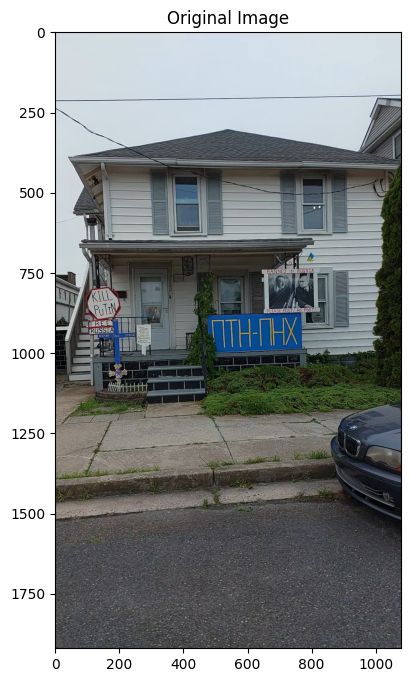

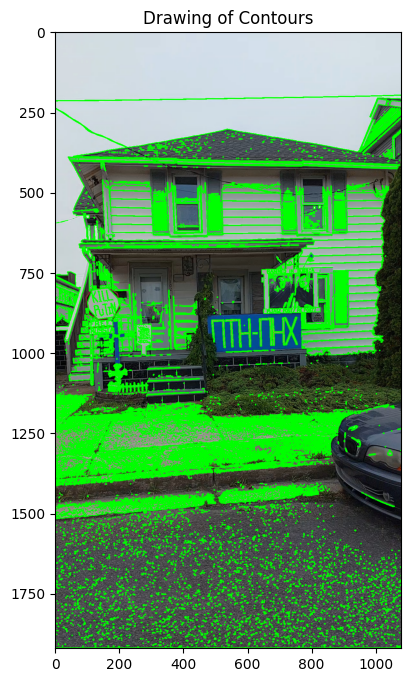

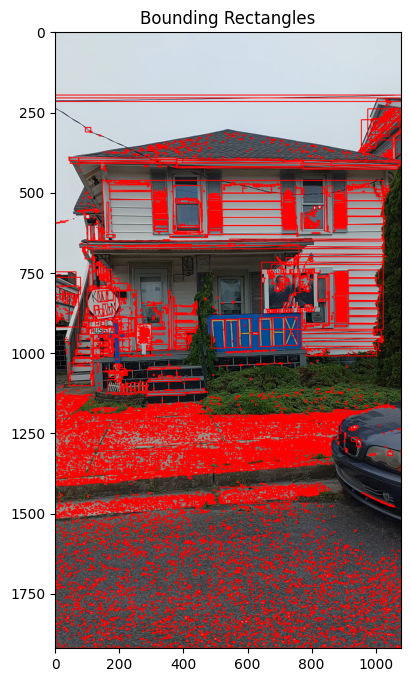

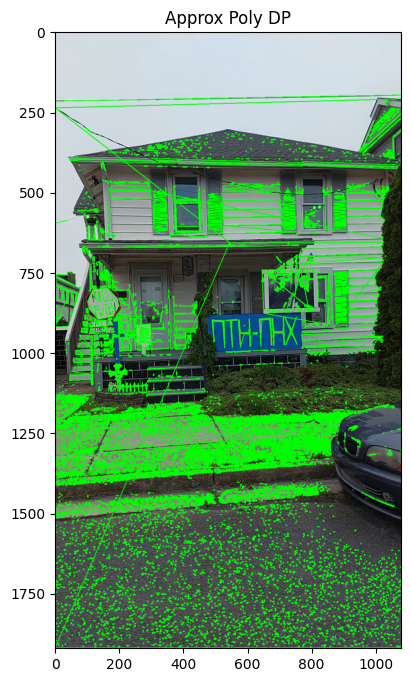

In [14]:
import numpy as np
import cv2

# Görüntüyü yükle ve bir kopyasını sakla
image = cv2.imread('../files/images/america14.jpg')
orig_image = image.copy()
imshow('Original Image', orig_image,8)
 
# Gri tonlama yap ve ikili tonla
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Konturları bul
contours, hierarchy = cv2.findContours(thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
copy = image.copy()

# Her kontur boyunca yinele
for c in contours:
    x,y,w,h = cv2.boundingRect(c)
    cv2.rectangle(orig_image,(x,y),(x+w,y+h),(0,0,255),2) 
    #c konturunu içine alan en küçük dikdörtgeni hesaplıyor.
    # (x,y) → dikdörtgenin sol üst köşesi. w,h → genişlik ve yükseklik
    cv2.drawContours(image, [c], 0, (0, 255, 0), 2)

imshow('Drawing of Contours', image,8)
imshow('Bounding Rectangles', orig_image,8)
# Iterate through each contour and compute the approx contour
for c in contours:
    # Calculate accuracy as a percent of the contour perimeter
    accuracy = 0.03 * cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, accuracy, True)
    cv2.drawContours(copy, [approx], 0, (0, 255, 0), 2)

    #accuracy = 0.03 * cv2.arcLength(c, True)
    #cv2.arcLength(c, True) → konturun çevresini (perimetre) hesaplar.
    #0.03 * … → bu çevrenin %3’ünü alıyoruz.
    #Bu değer epsilon olarak kullanılacak → yani yaklaşık poligonun orijinal konturdan 
    #ne kadar sapmasına izin verileceği.
    #Daha küçükoran → daha hassas sonuç (çok köşe).
    #Daha büyük oran → daha basitleştirilmiş sonuç (az köşe).

    #approx = cv2.approxPolyDP(c, accuracy, True)
    #Konturu daha az noktayla temsil eden poligon elde edilir.
    #accuracy → tolerans miktarı (ne kadar sadeleştirileceği).
    #True → konturun kapalı olduğunu belirtir (başlangıç ve bitiş noktası birleşir).
    #Sonuç → approx içinde konturun köşe noktaları vardır (örn: üçgen için 3, kare için 4, vs.).

    #cv2.drawContours(copy, [approx], 0, (0, 255, 0), 2)
    #copy üzerinde sadece sadeleştirilmiş konturu çiziyor.
    #[approx] → tek bir kontur verdiğimiz için liste içine alıyoruz.
    #(0,255,0) → yeşil renk
    #2 → çizgi kalınlığı
imshow('Approx Poly DP', copy,8)

## **Dışbükey Sarmalayıcıyı (Convex Hull)**

<img src="convex.png" width="400">

Dışbükey Sarmalayıcıyı kontur yaklaşımına benzer görünecektir, ancak değildir (Her ikisi de bazı durumlarda aynı sonuçları sağlayabilir).

cv2.convexHull() fonksiyonu bir eğriyi dışbükeylik kusurları açısından kontrol eder ve düzeltir. Genel olarak, dışbükey eğriler her zaman dışa doğru ve en azından düz olan eğrilerdir. Ve eğer içeride girintili ise buna dışbükeylik kusurları denir. Örneğin, aşağıdaki el resmini kontrol edin. 

Bu kodun amacı, eldeki şeklin dış sınırlarını bulup sadeleştirerek dışbükey sınır (convex hull) çizmek.
Bu, özellikle el hareketi tanıma ve parmak sayma uygulamalarında çok sık kullanılan bir adımdır. 

Bu kodun mantığı (kontur bulma + convex hull çıkarma), elden bağımsızdır.
👉 Genel amaç: Bir nesnenin en dış sınırını (en basit kabuğunu) bulmak.
El için çok popülerdir (parmak sayma, jest tanıma), ama şekil analizi, robotik, oyunlar, coğrafya, veri bilimi gibi birçok alanda da kullanılır.

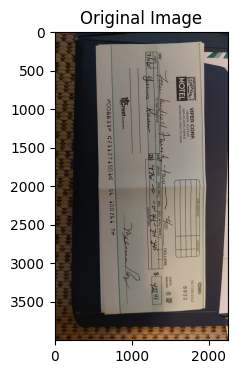

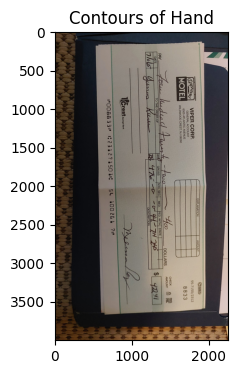

14070


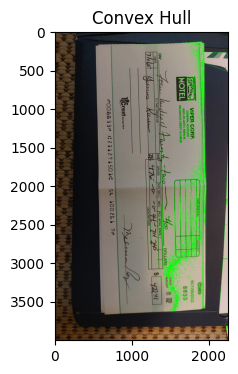

In [17]:
import numpy as np
import cv2

image = cv2.imread('../files/images/america17.jpg')
orginal_image = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

imshow('Original Image', image,4)

# Görüntüyü eşikleyelim
ret, thresh = cv2.threshold(gray, 176, 255, 0)

# Konturları Bulalım
contours, hierarchy = cv2.findContours(thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(image, contours, 0, (0, 255, 0), 2)
imshow('Contours of Hand', image,4)


# Konturları alana göre sıralayalım ve ardından en büyük çerçeve konturunu kaldıralım 
# En büyük kontur görüntünün kenarları veya arka planın oluşturduğu çerçeve benzeri büyük bir kontur olabilir.
n = len(contours) - 1
contours = sorted(contours, key=cv2.contourArea, reverse=False)[:n]
print(len(contours))

# Konturlar arasında tarama yapın ve dışbükey gövdeyi çizin
for c in contours:
    hull = cv2.convexHull(c)
    cv2.drawContours(orginal_image, [hull], 0, (0, 255, 0), 2)
    
imshow('Convex Hull', orginal_image,4)

# **Konturları Eşleştirme**
#### **cv2.matchShapes(contour template, contour, method, method parameter)**

**Output** – eşleşme değeri (düşük değerler daha yakın bir eşleşme anlamına gelir)

- Contour Template – Bu, yeni görüntüde bulmaya çalıştığımız referans konturumuzdur
- Contour – Kontrol ettiğimiz bireysel kontur
- Method – Kontur eşleştirme türü (1, 2, 3)
- Method Parameter – 0.0 olarak yalnız bırakın (python OpenCV'de tam olarak kullanılmaz)


Attempting to load template from: y:\MASAÜSTÜ\BilgisayarliGoru2025.V01\files\images\deneme2.png


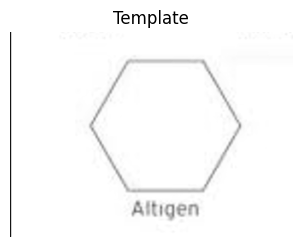

Attempting to load target from: y:\MASAÜSTÜ\BilgisayarliGoru2025.V01\files\images\deneme1.jpg
0.037157291922572076
3.8069823766558506e-12
0.0
3.0456715059952948e-12
0.0
3.0456715059952948e-12
3.0456715059952948e-12
6.852653882651146e-12
3.0456715059952948e-12


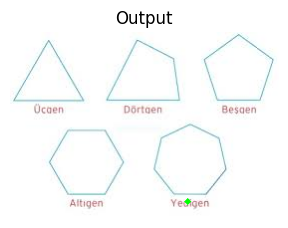

In [33]:
import cv2
import numpy as np
import os

# Şekil şablonunu veya referans görüntüsünü yükleyelim
template_candidates = [os.path.join('..','files','images','deneme2' + ext) for ext in ('.jpg', '.jpeg', '.png')]
template_path = None
for p in template_candidates:
    if os.path.exists(p):
        template_path = p
        break
if template_path is None:
    raise FileNotFoundError('Template file not found. Tried: ' + ', '.join(template_candidates))
print(f'Attempting to load template from: {os.path.abspath(template_path)}')
template = cv2.imread(template_path, 0)
if template is None:
    raise FileNotFoundError(f"Failed to load template image. Tried: {os.path.abspath(template_path)}")
imshow('Template', template,5)

# Hedef görüntüyü eşleştirmeye çalıştığımız şekillerle yükleyelim
target_candidates = [os.path.join('..','files','images','deneme1' + ext) for ext in ('.jpg', '.jpeg', '.png')]
target_path = None
for p in target_candidates:
    if os.path.exists(p):
        target_path = p
        break
if target_path is None:
    raise FileNotFoundError('Target file not found. Tried: ' + ', '.join(target_candidates))
print(f'Attempting to load target from: {os.path.abspath(target_path)}')
target = cv2.imread(target_path)
if target is None:
    raise FileNotFoundError(f"Failed to load target image. Tried: {os.path.abspath(target_path)}")
target_gray = cv2.cvtColor(target,cv2.COLOR_BGR2GRAY)

# cv2.findContours kullanmadan önce her iki görüntüyü de eşikleyelim
ret, thresh1 = cv2.threshold(template, 127, 255, 0)
ret, thresh2 = cv2.threshold(target_gray, 127, 255, 0)

# Şablondaki konturları bulun
contours, hierarchy = cv2.findContours(thresh1, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# Konturları alana göre sıralamamız gerekiyor, böylece en büyüğünü kaldırabiliriz
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Şablon konturumuz olacak ikinci en büyük konturu çıkarıyoruz
template_contour = contours[1] if len(contours) > 1 else (contours[0] if contours else None)
if template_contour is None:
    raise ValueError('Template contours not found.')

# İkinci hedef görüntüden konturları çıkarın
contours, hierarchy = cv2.findContours(thresh2, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

closest_contour = None
best_match = float('inf')
for c in contours:
    match = cv2.matchShapes(template_contour, c, 3, 0.0)
    print(match)
    if match < best_match:
        best_match = match
        closest_contour = c

# Apply threshold for acceptable match
if closest_contour is not None and best_match < 0.15:
    cv2.drawContours(target, [closest_contour], -1, (0,255,0), 3)
else:
    print(f'No matching contour found (best_match={best_match:.4f}, threshold=0.15).')

imshow('Output', target,5)